E_ref = 1 TeV 


In [1]:
import sys
sys.path.append('../')

import Dataset_load
from gammapy.modeling.models import Models

In [2]:
c = Dataset_load.load_config()
awo, aw, ewo, ew = c['_colors'] 
folder = c['folder']
livetime  = c['livetime']

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

In [3]:
def get_sym_datasets(sys, notes, nui, lt = f'_livetime_{livetime}'):
    models = []
    for s, n in zip (sys, notes):
        path = f'../{s}/data/0_model{nui}{lt}{n}.yml'
        models.append(Models.read(path))
    return models

In [4]:
sys = [
       'Eff_area_1TeV_10per_PKSflare_crab_cutoff',
       'E_reco_PKSflare_crab_cutoff',
    'Combined_1TeV_10per_PKSflare_crab_cutoff', 
      ]



notes = ["",  '', ""]

models_no = get_sym_datasets(sys, notes, nui  = "", lt = '' )


notes = ["_1000",  '_livetime_2.154434690031884_1000', "_1000"]

models_1tev_10per = get_sym_datasets(sys, notes, nui  = "_nui", lt = '' )



sys = [
       'Eff_area_1TeV_10per_PKSflare_crab_cutoff',
       'E_reco_PKSflare_crab_cutoff',
    'Combined_1TeV_10per_PKSflare_crab_cutoff', 
       
      ]

notes = ["_livetime_2.154434690031884_np",  '_livetime_2.154434690031884_1000', "_1000"]

models_1tev_np = get_sym_datasets(sys, notes, nui  = "_nui", lt = '' )





In [5]:
    
sys20 = [
       'Eff_area_1TeV_20per_PKSflare_crab_cutoff',
       'E_reco_double_PKSflare_crab_cutoff',
    'Combined_1TeV_20per_PKSflare_crab_cutoff', 
       
      ]
notes = ["_1000",  '_1000', "_1000"]

models_1tev_20per = get_sym_datasets(sys20, notes, nui  = "_nui", lt = '' )





In [6]:
energy_power = 2
alpha = 0.8
energy_bounds = (0.3, 100) *u.TeV
plot_minuit= 0
def plot_spectrum(model1, model2, ax, label1, label2):

    model1.spectral_model.plot(energy_bounds, energy_power = energy_power,
                                                 color = aw[0], ax = ax)    
    paris = [p.name for p in model1.spectral_model.parameters.free_parameters]
    model1.spectral_model.plot_error(energy_bounds,energy_power = energy_power, ax = ax, 
                                                   facecolor= aw[1], alpha = alpha,
                                                   label = label1)
       
    
    model2.spectral_model.plot(energy_bounds,energy_power = energy_power, ax = ax, 
                                               color= awo[0], linestyle = 'dashed')
    model2.spectral_model.plot_error(energy_bounds,energy_power = energy_power, ax = ax, 
                                                   facecolor= awo[1], alpha = alpha,
                                                   label = label2)
    ax.set_ylim(3e-13, 1e-10)

    ax.legend(loc = 'lower left')
    plt.tight_layout()
    ax.set_xlim(energy_bounds[0], energy_bounds[1])
    #ax.set_ylim(4e-13, 8e-11)
    
    yl = ax.get_ylabel()
    ax.set_ylabel("e2" + yl)#"dnde [$\mathrm{TeV\,s^{-1}\,cm^{-2}}$]}")
    return fig
        

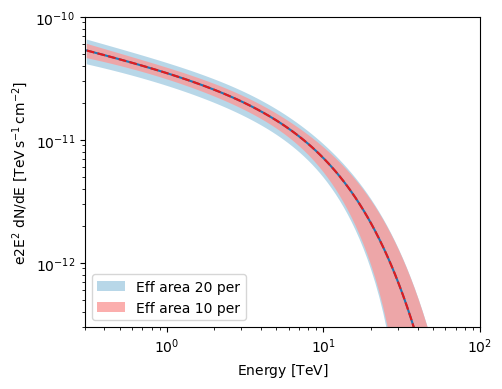

In [7]:
fig,ax = plt.subplots(1, 1, figsize = (5, 4 ))
fig = plot_spectrum(model1= models_1tev_20per[0][0],
                    model2= models_1tev_10per[0][0],
                    ax = ax, 
                   label1 = 'Eff area 20 per',
                   label2 = 'Eff area 10 per')

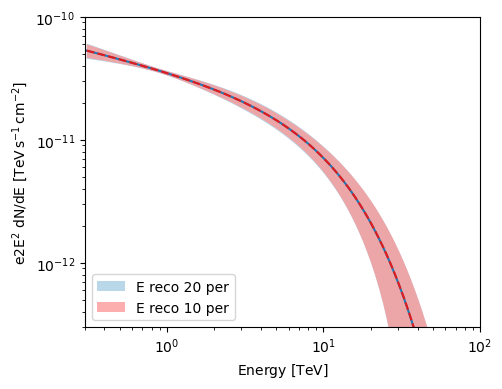

In [8]:
fig,ax = plt.subplots(1, 1, figsize = (5, 4 ))
fig = plot_spectrum(model1= models_1tev_20per[1][0],
                    model2= models_1tev_10per[1][0],
                    ax = ax, 
                   label1 = 'E reco 20 per',
                   label2 = 'E reco 10 per')

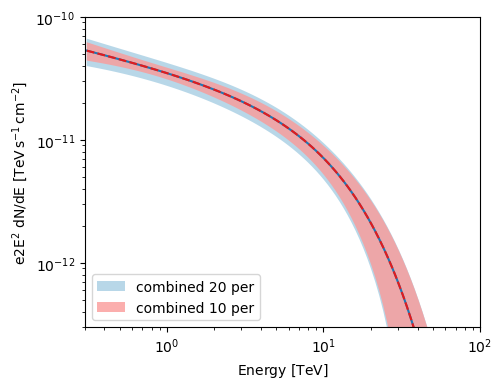

In [9]:
fig,ax = plt.subplots(1, 1, figsize = (5, 4 ))
fig = plot_spectrum(model1= models_1tev_20per[2][0],
                    model2= models_1tev_10per[2][0],
                    ax = ax, 
                   label1 = 'combined 20 per',
                   label2 = 'combined 10 per')

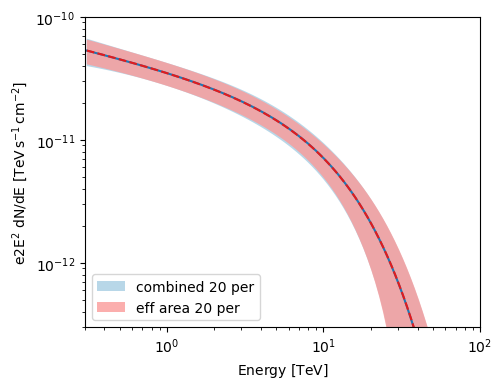

In [10]:
fig,ax = plt.subplots(1, 1, figsize = (5, 4 ))
fig = plot_spectrum(model1= models_1tev_20per[2][0],
                    model2= models_1tev_20per[0][0],
                    ax = ax, 
                   label1 = 'combined 20 per',
                   label2 = 'eff area 20 per')

## Index

In [11]:
for m in models_1tev_10per:
    par = m.parameters['index']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

index
2.302  \pm  0.09218 
index
2.299  \pm  0.1291 
index
2.299  \pm  0.1396 


In [12]:
for m in models_1tev_20per:
    par = m.parameters['index']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

index
2.302  \pm  0.09817 
index
2.298  \pm  0.1438 
index
2.299  \pm  0.1435 


## amplitude

In [13]:
for m in models_1tev_10per:
    par = m.parameters['amplitude']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

amplitude
3.849e-11  \pm  4.652e-12 
amplitude
3.852e-11  \pm  2.607e-12 
amplitude
3.853e-11  \pm  4.706e-12 


In [14]:
for m in models_1tev_20per:
    par = m.parameters['amplitude']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

amplitude
3.849e-11  \pm  8.382e-12 
amplitude
3.854e-11  \pm  2.669e-12 
amplitude
3.853e-11  \pm  8.418e-12 


## lambda_

In [15]:
for m in models_1tev_10per:
    par = m.parameters['lambda_']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

lambda_
0.09952  \pm  0.03891 
lambda_
0.09988  \pm  0.03984 
lambda_
0.1  \pm  0.04037 


In [16]:
for m in models_1tev_20per:
    par = m.parameters['lambda_']
    print(par.name)
    try:
        print(f'{par.value:.4}  \pm  {par.error:.4} -{par.error_n:.4}  +{par.error_p:.4}')
    except:
        print(f'{par.value:.4}  \pm  {par.error:.4} ')
        

lambda_
0.09952  \pm  0.03891 
lambda_
0.1002  \pm  0.04081 
lambda_
0.1  \pm  0.04037 


In [17]:
from gammapy.modeling import Parameter
import numpy as np
def round_par(p):
    i = 2
    
    if p.name == 'amplitude':
        rounded_par = Parameter(value = np.round(p.value*1e11, decimals=i), 
                            error = np.round(p.error*1e11, decimals=i), 
                            error_n = np.round(p.error_n*1e11, decimals=i),
                            error_p = np.round(p.error_p*1e11, decimals=i),
                            name = p.name)
    
    else:
        rounded_par = Parameter(value = np.round(p.value, decimals=i), 
                            error = np.round(p.error, decimals=i), 
                            error_n = np.round(p.error_n, decimals=i),
                            error_p = np.round(p.error_p, decimals=i),
                            name = p.name)
    return rounded_par


def round_par_sym(p):
    i = 3
    
    if p.name == 'amplitude':
        rounded_par = Parameter(value = np.round(p.value*1e11, decimals=i), 
                            error = np.round(p.error*1e11, decimals=i), 
                            name = p.name)

    else:
        rounded_par = Parameter(value = np.round(p.value, decimals=i), 
                            error = np.round(p.error, decimals=i), 
                            name = p.name)
    return rounded_par


                            

In [18]:
headline = "\\textbf{Point Source} &  $\Phi_0\ [10^{-11}\, \\text{cm}^{-2}\, \\text{s}^{-1}\,\\text{TeV}^{-1}]$  & $\Gamma$ & $\lambda = 1/E_c\ [\\text{TeV}^{-1}]$  & $\sigma\, [\\text{deg}]$ \\\ \hline \hline"
input_ = ' Simulation input & $3.85 $  & $2.30 $  & $0.10 $ & --   \\\  \hline'


parameters = ['amplitude', 'index', 'lambda_']
text = ['no systematics ', 
        f'$10\%$ systematics on $A_{{\\text{{eff}}}}$',
       f'$20\%$ systematics on $A_{{\\text{{eff}}}}$',
        
       f'$10\%$ systematics on $E_{{\\text{{disp}}}}$',
        f'$20\%$ systematics on $E_{{\\text{{disp}}}}$',
        
       f'$10\%$systematics on $A_{{\\text{{eff}}}}$ \& $E_{{\\text{{disp}}}}$',
       f'$20\%$systematics on $A_{{\\text{{eff}}}}$ \& $E_{{\\text{{disp}}}}$']
     

print_models = [models_no[0],
                models_1tev_10per[0], 
                models_1tev_20per[0], 
                
                models_1tev_10per[1], 
                models_1tev_20per[1],  
                
                models_1tev_10per[2],
                models_1tev_20per[2],]


print(headline)
print(input_)
print()


sym = True
for m, t in zip(print_models, text): 
    string = t
    for p_name in parameters:
        if sym:
            par = round_par_sym(m.parameters[p_name])
            string += rf' & \errorsym {{{par.value:.3}}} {{{par.error:.2}}} '
        else:
            par = round_par(m.parameters[p_name])
            string += rf' & \error {{{par.value:.3}}} {{{par.error:.2}}}  {{{par.error_p:.3}}}  {{{par.error_n:.3}}} '
    
    if "$10\%$" in string:
        string +=  '\\\  '
    else:
        string +=  '\\\  \hline'
        
    print(string)
    print()
    
        



\textbf{Point Source} &  $\Phi_0\ [10^{-11}\, \text{cm}^{-2}\, \text{s}^{-1}\,\text{TeV}^{-1}]$  & $\Gamma$ & $\lambda = 1/E_c\ [\text{TeV}^{-1}]$  & $\sigma\, [\text{deg}]$ \\ \hline \hline
 Simulation input & $3.85 $  & $2.30 $  & $0.10 $ & --   \\  \hline

no systematics  & \errorsym {3.85} {0.26}  & \errorsym {2.3} {0.092}  & \errorsym {0.1} {0.04} \\  \hline

$10\%$ systematics on $A_{\text{eff}}$ & \errorsym {3.85} {0.47}  & \errorsym {2.3} {0.092}  & \errorsym {0.1} {0.039} \\  

$20\%$ systematics on $A_{\text{eff}}$ & \errorsym {3.85} {0.84}  & \errorsym {2.3} {0.098}  & \errorsym {0.1} {0.039} \\  \hline

$10\%$ systematics on $E_{\text{disp}}$ & \errorsym {3.85} {0.26}  & \errorsym {2.3} {0.13}  & \errorsym {0.1} {0.04} \\  

$20\%$ systematics on $E_{\text{disp}}$ & \errorsym {3.85} {0.27}  & \errorsym {2.3} {0.14}  & \errorsym {0.1} {0.041} \\  \hline

$10\%$systematics on $A_{\text{eff}}$ \& $E_{\text{disp}}$ & \errorsym {3.85} {0.47}  & \errorsym {2.3} {0.14}  & \errorsy

## Scans 

In [19]:
import yaml
parameter_names = c['parameter_names']        

parameter_names_1  = set(list(np.array(parameter_names).ravel()))
for p in parameter_names_1:
    print(p)


def read_in_scan(folder, note):
    results = []
    for parname1 in parameter_names_1 :
        #try:
        with open(f"../{folder}/data/4_scan_{note}_{parname1}_{numpoints}.yml", "r") as stream:
                contour = yaml.safe_load(stream)
        #except:
        #    with open(f"../{folder}/data/4_scan_{note}_{parname1}.yml", "r") as stream:
        #        contour = yaml.safe_load(stream)
        results.append(contour)
    return results


amplitude
index
lambda_


In [23]:
numpoints = 20
results_eff_nosys = read_in_scan(folder = sys[0], note = "2.15h", )
results_eff_10 = read_in_scan(folder = sys[0], note = "N_2.15h", )
results_eff_20 = read_in_scan(folder = sys20[0], note = "N_2.15h", )


results_ereco_nosys = read_in_scan(folder = sys[1], note = "2.15h", )
results_ereco_10 = read_in_scan(folder = sys[1], note = "N_2.15h", )
results_ereco_20 = read_in_scan(folder = sys20[1], note = "N_2.15h", )


#results_com_10 = read_in_scan(folder = sys[2], note = "2.15h", )
#results_com_20 = read_in_scan(folder = sys20[2], note = "2.15h", )


Text(0.5, 0, 'amplitude')

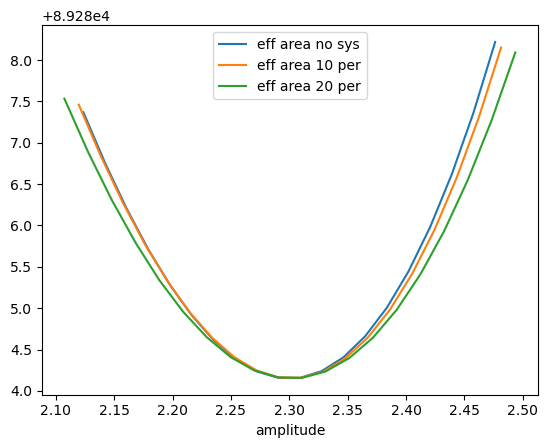

In [24]:
idx = 1

xnosys = results_eff_nosys[idx][list(results_eff_10[idx].keys())[0]]
ynosys = results_eff_nosys[idx][list(results_eff_10[idx].keys())[1]]

x = results_eff_10[idx][list(results_eff_10[idx].keys())[0]]
y = results_eff_10[idx][list(results_eff_10[idx].keys())[1]]

x20 = results_eff_20[idx][list(results_eff_10[idx].keys())[0]]
y20 = results_eff_20[idx][list(results_eff_10[idx].keys())[1]]

plt.plot(xnosys,ynosys, label = 'eff area no sys')
plt.plot(x,y, label = 'eff area 10 per')
plt.plot(x20,y20, label = 'eff area 20 per')
plt.legend()
plt.xlabel("amplitude")


Text(0.5, 0, 'index')

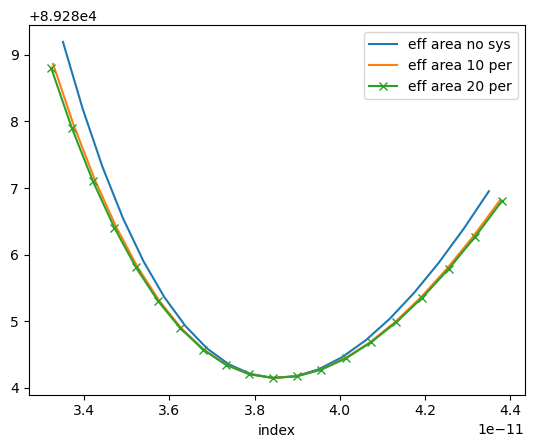

In [25]:
idx = 0

xnosys = results_ereco_nosys[idx][list(results_eff_nosys[idx].keys())[0]]
ynosys = results_ereco_nosys[idx][list(results_eff_nosys[idx].keys())[1]]

x = results_ereco_10[idx][list(results_eff_10[idx].keys())[0]]
y = results_ereco_10[idx][list(results_eff_10[idx].keys())[1]]

x20 = results_ereco_20[idx][list(results_eff_10[idx].keys())[0]]
y20 = results_ereco_20[idx][list(results_eff_10[idx].keys())[1]]

plt.plot(xnosys,ynosys, label = 'eff area no sys')
plt.plot(x,y, label = 'eff area 10 per')
plt.plot(x20,y20, label = 'eff area 20 per', marker = 'x')
plt.legend()
plt.xlabel("index")
